# **Machine Learning--1**

## **Program 1**

Dataset loaded successfully.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 


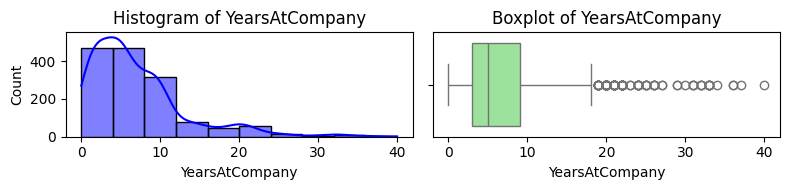

Outliers in (num_column): 104
18      25
28      22
45      22
62      27
63      21
        ..
1403    20
1404    20
1443    22
1445    20
1462    20
Name: YearsAtCompany, Length: 104, dtype: int64

Enter the name of a categorical column: Attrition
Choose chart type (bar/pie): pie


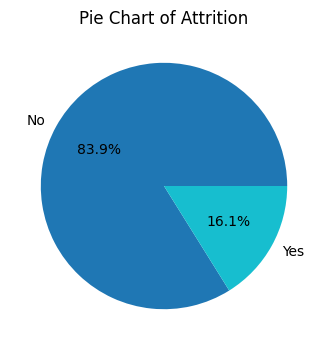

Frequency of categories in Attrition:
Attrition
No     1233
Yes     237
Name: count, dtype: int64



In [4]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("/content/EDAibm_hr_employee-attrition.csv")
print("Dataset loaded successfully.")
data.info()

# Identify numerical and categorical columns
num_columns = data.select_dtypes (include=['number']).columns
cat_columns = data.select_dtypes (exclude=['number']).columns
print(f"\nNumerical columns ({len (num_columns)}): {list(num_columns)}")
print (f"Categorical columns ({len(cat_columns)}): {list(cat_columns)}")

# Numerical column analysis
num_column = input("\nEnter the name of a numerical column:")
if num_column in data.columns:
    column_data = data[num_column]
    mean = column_data.mean()
    median = column_data.median()
    mode = column_data.mode().iloc[0] if not column_data.mode().empty else None
    std_dev = column_data.std()
    variance = column_data.var()
    value_range = column_data.max() - column_data.min()
    print(f"Statistics for {num_column}:\n")
    print (f"Mean: {mean}")
    print(f"Median: {median}")
    print (f"Mode: {mode}")
    print (f"Standard Deviation: {std_dev}")
    print(f"Variance: {variance}")
    print (f"Range: {value_range}\n")
    # Generate histogram and boxplot
    plt.figure(figsize=(8, 2))
    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(column_data, kde = True, bins=10, color='blue')
    plt.title(f"Histogram of {num_column}")
    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=column_data, color='lightgreen')
    plt.title(f"Boxplot of {num_column}")
    plt.tight_layout()
    plt.show()

    q2 = column_data.quantile(0.25)
    q3 = column_data.quantile(0.75)
    iqr = q3 - q2
    lower_bound = q2 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    outliers = column_data[(column_data < lower_bound) | (column_data > upper_bound)]
    print(f"Outliers in (num_column): {len (outliers)}")
    print (outliers)
else:
    print(f"Column '{num_column}' not found in the dataset.")

# Categorical column analysis
cat_column = input("\nEnter the name of a categorical column: ")
if cat_column in data.columns:
    category_counts = data[cat_column].value_counts()
    chart_type = input("Choose chart type (bar/pie): ")
    if chart_type == 'bar':
        category_counts.plot(kind='bar', color='orange', figsize=(5, 3))
        plt.title(f"Bar Chart of {cat_column}")
        plt.xlabel(cat_column)
        plt.ylabel("Frequency")
        plt.xticks (fontsize=8)
        plt.xticks (rotation=45,ha='right')
        plt.show()
    elif chart_type == 'pie':
        category_counts.plot(kind='pie', autopct="%.1f%%", figsize=(4, 4), colormap='tab10')
        plt.title(f"Pie Chart of {cat_column}")
        plt.ylabel("")
        plt.show()
    else:
        print("Invalid chart type. Please use 'bar' or 'pie'.")
    print(f"Frequency of categories in {cat_column}:\n{category_counts}\n")
else:
    print(f"Column '{cat_column}' not found in the dataset.")

## **Program 2**

Pearson Correlation Coefficient: 
               sepal_length  petal_length
sepal_length      1.000000      0.871754
petal_length      0.871754      1.000000
Covariance Matrix:
               sepal_length  petal_length
sepal_length      0.685694      1.274315
petal_length      1.274315      3.116278


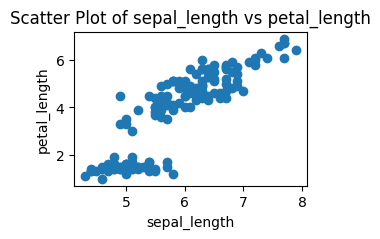

Covariance Matrix:
               sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006

 Correlation Matrix:
               sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


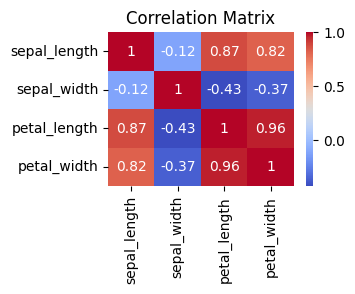

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the Iris dataset
data = sns.load_dataset('iris')
# Select two numerical columns for scatter plot and correlation calculation
x_col = 'sepal_length'
y_col = 'petal_length'
correlation = data[['sepal_length', 'petal_length']].corr('pearson')
print("Pearson Correlation Coefficient: \n", correlation)
# Compute covariance matrix
covariance = data[['sepal_length', 'petal_length']].cov()
print("Covariance Matrix:\n", covariance)

# Create scatter plot
plt.figure(figsize=(3,2))
plt.scatter(data[x_col], data[y_col])
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title(f"Scatter Plot of {x_col} vs {y_col}")
plt.show()


# Calculate covariance and correlation matrix for a dataset
data_co = data.iloc[:, : -1]
covariance_matrix = data_co.cov()
correlation_matrix = data_co.corr()
print("Covariance Matrix:\n", covariance_matrix)
print("\n Correlation Matrix:\n", correlation_matrix)

# Visualize correlation matrix using heatmap
plt.figure(figsize=(3,2))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## **Program 3**

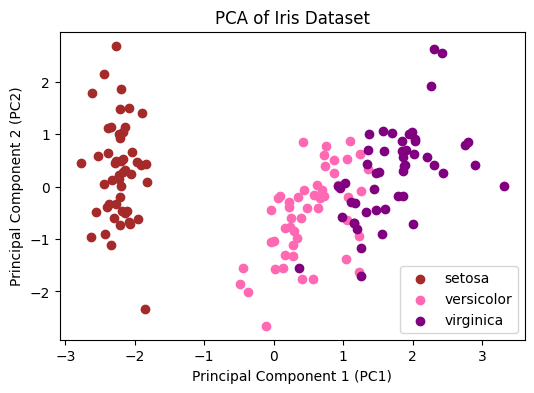

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()
X = iris.data # Features (4 dimensions)
y = iris.target # Labels

# Standardize the data (mean=0, variance=1)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_std =scaler.fit_transform(X)

# Apply PCA to reduce the dimensionality to 2 components
pca = PCA(n_components=2)
X_pca =pca.fit_transform(X_std)

# Create a DataFrame for the reduced data
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Species'] = y

# Visualize the reduced data
plt.figure(figsize=(6, 4))
species = ['Setosa', 'Versicolor', 'Virginica']
colors = ['brown', 'hotpink', 'purple']
for species, color in zip(np.unique(y), colors):
    plt.scatter(df_pca.loc[df_pca['Species'] == species, 'PC1'], df_pca.loc[df_pca['Species'] == species, 'PC2'], c=color, label=iris.target_names [species])
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.title('PCA of Iris Dataset')
plt.legend()
plt.show()

## **Program 4**

In [5]:
# import the Libraries
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

#Load the Iris dataset
iris = load_iris()
X = iris.data # Features
y = iris.target # Labels
#Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Function to evaluate k-NN for different values of k
def cls_knn(X_train, X_test, y_train, y_test, k_values, weighted=False):
    results = {}
    for k in k_values:
        if weighted:
            #Weighted k-NN
            knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
        else:
            # Regular k-NN
            knn = KNeighborsClassifier(n_neighbors=k, weights='uniform')

        # Train the model
        knn.fit(X_train, y_train)
        # Make predictions
        y_pred = knn.predict(X_test)
        # Calculate accuracy and F1-score
        accuracy = accuracy_score (y_test, y_pred)
        # Weighted F1-score for multi-class
        f1 = f1_score(y_test, y_pred, average='weighted')
        results[k] = {'accuracy': accuracy, 'f1_score': f1}
    return results

#Test for different values of k
k_values = [1, 3, 5]

# Evaluate regular k-NN
print("Regular k-NN Results:")
regular_results = cls_knn (X_train, X_test, y_train, y_test, k_values, weighted=False)
for k, metrics in regular_results.items():
    print(f"k={k}: Accuracy={metrics['accuracy']:.2f}, F1-Score={metrics['f1_score']:.2f}")

# Evaluate weighted k-NN
print("\nWeighted k-NN Results:")
weighted_results = cls_knn(X_train, X_test, y_train, y_test, k_values, weighted=True)
for k, metrics in weighted_results.items():
    print(f"k={k}: Accuracy={metrics['accuracy']:.2f}, F1-Score={metrics['f1_score']:.2f}")


# Compare performance
print("\nComparison of Regular k-NN and Weighted k-NN:")
for k in k_values:
    regular_acc = regular_results[k]['accuracy']
    weighted_acc = weighted_results[k]['accuracy']
    print(f"k={k}: Regular k-NN Accuracy={regular_acc:.2f}, Weighted k-NN Accuracy={weighted_acc:.2f}")

Regular k-NN Results:
k=1: Accuracy=1.00, F1-Score=1.00
k=3: Accuracy=1.00, F1-Score=1.00
k=5: Accuracy=1.00, F1-Score=1.00

Weighted k-NN Results:
k=1: Accuracy=1.00, F1-Score=1.00
k=3: Accuracy=1.00, F1-Score=1.00
k=5: Accuracy=1.00, F1-Score=1.00

Comparison of Regular k-NN and Weighted k-NN:
k=1: Regular k-NN Accuracy=1.00, Weighted k-NN Accuracy=1.00
k=3: Regular k-NN Accuracy=1.00, Weighted k-NN Accuracy=1.00
k=5: Regular k-NN Accuracy=1.00, Weighted k-NN Accuracy=1.00


## **Program 5**

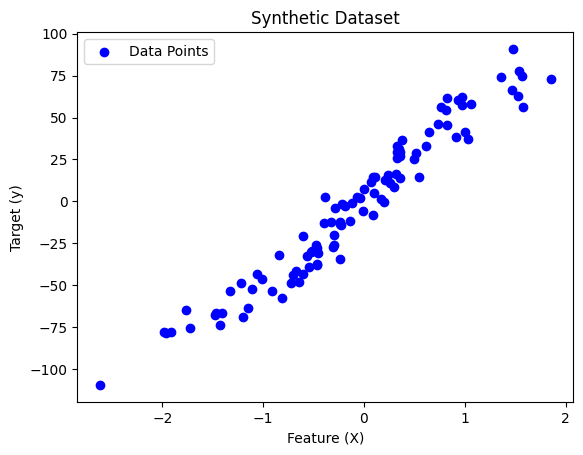

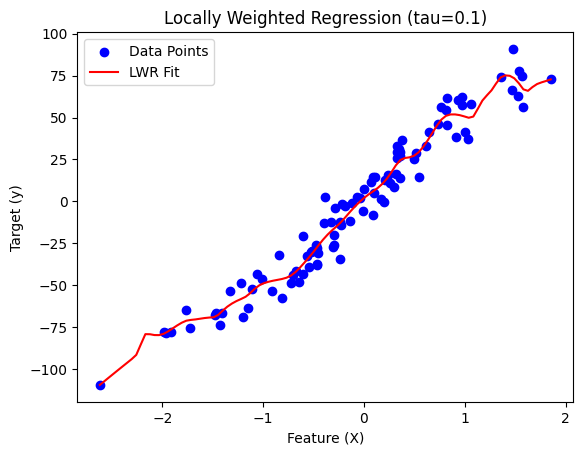

Mean Squared Error (MSE) on Training Data: 64.7316


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error

# Generate a synthetic dataset
np.random.seed(42)
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)
# Add some non-linearity to the dataset
y = y + 10 * np.sin(X[:, 0] * 2)

# Plot the dataset
plt.scatter(X, y, color='blue', label='Data Points')
plt.title("Synthetic Dataset")
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.legend()
plt.show()

# Locally Weighted Regression function
def locally_weighted_regression (X, y, query_point, tau=0.1):
    # Compute weights using a Gaussian kernel
    weights = np.exp(-np.sum((X - query_point) ** 2, axis=1) / (2 * tau ** 2))
    # Add a bias term to X
    X_bias= np.c_[np.ones(X.shape[0]), X]
    # Compute the weighted least squares solution
    W= np.diag(weights)
    theta = np.linalg.inv(X_bias.T @ W @X_bias) @ (X_bias.T @ W @ y)
    # Predict the target value for the query point
    query_point_bias= np.array ([1, query_point[0]])
    y_pred = query_point_bias @ theta
    return y_pred

# Predict using Locally Weighted Regression
def predict_lwr (X_train, y_train, X_test, tau=0.1):
    y_pred = np.zeros(X_test.shape[0])
    for i, query_point in enumerate (X_test):
        y_pred[i] = locally_weighted_regression(X_train, y_train, query_point, tau)
    return y_pred

# Generate test points
X_test = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# Predict using LWR
tau = 0.1 # Bandwidth parameter
y_pred = predict_lwr (X, y, X_test, tau)

# Plot the results
plt.scatter(X, y, color='blue', label='Data Points')
plt.plot(X_test, y_pred, color='red', label='LWR Fit')
plt.title(f"Locally Weighted Regression (tau={tau})")
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.legend()
plt.show()

# Evaluate the model
mse = mean_squared_error(y, predict_lwr (X, y, X, tau))
print (f"Mean Squared Error (MSE) on Training Data: {mse:.4f}")

## **Program 6**

### **Program 6-Linear Regression**

Linear Regression on Boston Housing Dataset
Mean Squared Error: 46.1448
R^2 Score: 0.3708


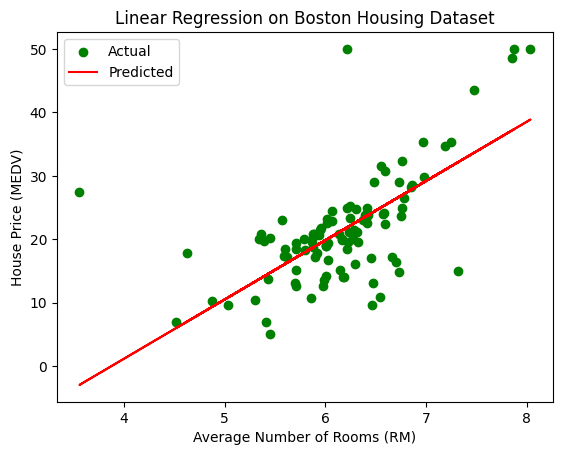

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the Boston Housing Dataset
boston_df = pd.read_csv("/content/boston_housing_data.csv")
print("Linear Regression on Boston Housing Dataset")

X = boston_df[['RM']]  # Using 'RM' (average number of rooms) as the feature
y = boston_df['MEDV']  # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Linear Regression model
LR_model = LinearRegression()
LR_model.fit(X_train, y_train)

# Make predictions
y_pred = LR_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R^2 Score: {r2:.4f}")

# Plot the results
plt.scatter(X_test, y_test, color='green', label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted')
plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('House Price (MEDV)')
plt.title('Linear Regression on Boston Housing Dataset')
plt.legend()
plt.show()

### **Program 6-Polynomial Regression**

Polynomial Regression on Auto MPG Dataset
Mean Squared Error: 18.4170
R^2 Score: 0.6392


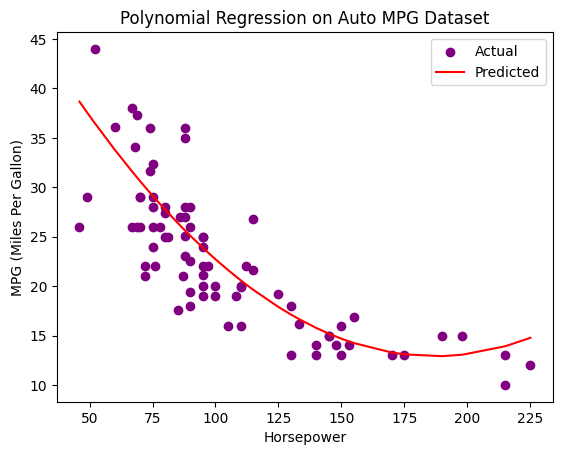

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# Load Auto MPG Dataset for Polynomial Regression
auto_df = pd.read_csv("/content/auto-mpg.csv")
print("Polynomial Regression on Auto MPG Dataset")

# Drop rows with missing values in the Auto MPG dataset
auto_df['horsepower'] = auto_df['horsepower'].replace('?', np.nan).astype(float)
auto_df.dropna(inplace=True) #Drop rows with NaN values

X = auto_df[['horsepower']]  # Using 'horsepower' as the feature
y = auto_df['mpg']  # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Transform features to polynomial features (degree=2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Create and train the Polynomial Regression model
PR_model = LinearRegression()
PR_model.fit(X_train_poly, y_train)

# Make predictions
y_pred = PR_model.predict(X_test_poly)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R^2 Score: {r2:.4f}")

# Plot the results
plt.scatter(X_test, y_test, color='purple', label='Actual')
sorted_indices = X_test.squeeze().argsort()
plt.plot(X_test.iloc[sorted_indices], y_pred[sorted_indices], color='red', label='Predicted')
plt.xlabel('Horsepower')
plt.ylabel('MPG (Miles Per Gallon)')
plt.title('Polynomial Regression on Auto MPG Dataset')
plt.legend()
plt.show()